# Constrained Cobb-Douglas with MPC: Theory and Hold-Out Results

The live intraday Cobb-Douglas (CD) engine that ran from 2026-05-05 to 2026-05-15 on a paper account was discontinued at market close on 2026-05-18 with a flat-with-bleed P&L. The diagnostic was clean: the allocator solved unconstrained CD at a 30-min clock, the turnover gate was disabled, and γ jitter at 30-min cadence was being rounded into ±1-share orders on 5-10 tickers per fire. The engine had no notion of cost, no notion of risk, no notion of holding, and fired on a clock with no information content.

This notebook walks through the design that replaces it: a **constrained Cobb-Douglas allocator** (covariance, turnover, and concentration budgets) wrapped in **model-predictive control (MPC)** discipline (forward-project, fire only when the realized path leaves a confidence band). The universe is a 33-ticker basket frozen from the S4 per-sector bandit (uniform 3-per-sector GICS quotas). We benchmark the design against five baselines on the 2025-2026 hold-out window with after-cost, after-tax accounting.

> **Learning Objectives:**
>
> * __Constrained allocation as a convex program:__ State the budget, covariance, turnover, and concentration constraints that wrap the Cobb-Douglas objective. Recognize that the resulting program is convex and solves in milliseconds at production basket sizes.
> * __Event-driven rebalancing:__ Define the MPC in-spec band and the three trigger conditions that decide when re-allocation fires. Explain why event-driven cadence replaces the live engine's information-free clock.
> * __Pairwise strategy comparison:__ Read the six-strategy bake-off and identify which row pairs isolate the cadence effect, the constraint effect, and the combined fix. Interpret a surprising or unexpected ranking against the design intent.

Let's walk through the theory and read the bake-off.


___
## Section 1: Theory

In this section, let's take a look at the constrained Cobb-Douglas formulation and the model predictive control (MPC) trigger conditions. We'll start by looking at a reformulated Cobb-Douglas allocation problem, then we'll examine the three trigger conditions that define the MPC discipline, and then wer'll end with a high-level algorithm that wraps the allocator in the MPC discipline.

### Constrained Cobb-Douglas Allocation with MPC Discipline
The idea behind the constrained Cobb-Douglas formulation is to wrap the classic Cobb-Douglas objective in constraints that are interpretable in client terms: a budget constraint, a covariance (risk) constraint, a turnover constraint, and a concentration constraint. The MPC discipline then defines when to fire the (re)allocator based on forward projections of the portfolio value.

> **Constrained Cobb-Douglas (CD) Optimization**
>
> Given a basket of $K$ tickers, share prices $\mathbf{p} \in \mathbb{R}^K_{>0}$, investment budget $B$, prior shares $\mathbf{n}_{\text{prev}} \in \mathbb{R}^K_{>0}$, single index model (SIM)-implied covariance $\boldsymbol{\Sigma}\in \mathbb{R}^{K \times K}$, and per-share average cost $\bar{c}\in \mathbb{R}_{>0}$, solve this optimization problem for the number of new shares $\mathbf{n}_{\tau}$ at time $\tau$:
>
> $$\max_{n_i > 0} \; \sum_{i=1}^{K} \gamma_i \log(n_i)$$
>
> where the objective is the log of the Cobb-Douglas utility function. The optimization is subject to the constraints:
>
> $$\sum_i n_i p_i \le B, \quad \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \le \sigma_{\max}^2, \quad \bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}, \quad w_i \le w_{\max}, \quad n_i > 0$$
>
> where $w_i = n_i p_i / B$, $K_{\text{turnover}}$ denotes the turnover budget, and $\|\star\|_1$ is the L1 norm. Strict positivity ($n_i > 0$) is required for the log objective to be finite; the solver enforces it numerically as $n_i \ge \varepsilon$ with $\varepsilon = 10^{-8}$, and pins non-preferred names ($\gamma_i \le 0$) at $\varepsilon = 10^{-3}$ shares before optimizing over the preferred subset. 
> 
> __Design variables__: The two knobs $\sigma_{\max}$ (annualized portfolio vol cap; default in growth-rate-vol units) and $K_{\text{turnover}}$ (dollar turnover budget per decision; default 10% of $B$) are interpretable in client terms. The preference vector $\boldsymbol{\gamma}$ has scalar entries $\gamma_i$ computed from SIM regression parameters and the regime-lens $\lambda$ (no news term). The covariance is the SIM decomposition $\boldsymbol{\Sigma} = \sigma_m^2 \boldsymbol{\beta}\boldsymbol{\beta}^\top + \mathrm{diag}(\sigma_{\varepsilon,i}^2)$, built from the same parameters that drive $\boldsymbol{\gamma}$.

The block above specifies *what* to hold at a decision time. However, it does not specify *when* a decision time occurs. The next block specifies *when* a decision time occurs. We specify a __trigger condition__ on the forward-projected portfolio value that decides when to fire the allocator. Between triggers, the engine submits no orders and holds the current position.

> **Model predictive control (MPC) trigger conditions:**
>
> At decision time $t$, we forward-project the portfolio value $T$ days in the future, given the current allocation, that is $V_\tau$ for $\tau = t+1, \ldots, t+T$ by sampling $N$ paths from the SPY-JumpHMM marginal + SIM hybrid: $g_{i,\tau}^{(j)} = \alpha_i + \beta_i\, g_{m,\tau}^{(j)} + \varepsilon_{i,\tau}^{(j)}$, where $g_{i,\tau}^{(j)}$ is the growth rate for asset $i$ at time $\tau$ under scenario $j$, i.e., path $j$. 
> 
> The realized path is **in-spec** at time $\tau$ iff
>
> $$\mu_\tau - z\,\sigma_\tau \;\le\; V_\tau \;\le\; \mu_\tau + z\,\sigma_\tau$$
>
> with defaults $z = 1.96$, $T = 21$ trading days. Re-allocation fires when **any** of: (1) $V_\tau$ exits the band on the realized path, (2) $T$ days have elapsed since the last allocation, (3) realized drawdown from peak exceeds $D_{\max} = 8\%$. Between triggers the engine submits no orders. This is the discipline that fixes the live failure mode.

#### Algorithm: Constrained CD with MPC (Hold-Out Deployment Loop)

__Initialize__: Given the frozen 33-ticker basket $\mathcal{B}$, risk parameters $\sigma_{\max}$, $K_{\text{turnover}}$, $w_{\max}$, MPC parameters $z$, $T$, $D_{\max}$, and initial position $\mathbf{n}_{\text{prev}} \gets \mathbf{0}$.

For each trading day $\tau$ in the hold-out window $[2025\text{-}01\text{-}02,\, 2026\text{-}04\text{-}22]$ __do__:

1. Compute $\boldsymbol{\gamma}_\tau$ from SIM parameters, the EMA-based regime-lens $\lambda_\tau$, and the smoothed market growth $g_{m,\tau}$.
2. Forward-project $N$ paths over $[\tau, \tau + T]$ and form the in-spec band $[\mu_\tau - z\sigma_\tau,\; \mu_\tau + z\sigma_\tau]$.
3. Check the three trigger conditions on the current portfolio.
4. If any trigger fires, solve the constrained CD problem for $\mathbf{w}_\tau^\star$; translate to integer shares $\mathbf{n}_\tau$; route the order set through the cost + tax engine.
5. Update $\mathbf{n}_{\text{prev}} \gets \mathbf{n}_\tau$; log the trigger reason and the turnover consumed.
6. Otherwise hold; submit no orders.

__Output__: Wealth path $\{V_\tau\}$, trigger log, after-cost after-tax summary.

### Baseline Strategies for Comparison
> **Baselines (five strategies compared against ConstrainedCDWithMPC):**
>
> All five use the same frozen 33-ticker basket and the same after-cost / after-tax engine; they differ only in the allocator and the rebalance cadence.
>
> **(1) EqualWeight (buy-and-hold):** $w_i = 1/K$ set once on day 1.
>
> **(2) MinVar (buy-and-hold):** solve
> $$\min_{\mathbf{w}} \; \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \quad \text{s.t.} \quad \sum_i w_i = 1,\; w_i \ge 0$$
> on the training-window $\boldsymbol{\Sigma}$, then hold. The S1 baseline.
>
> **(3) UnconstrainedCD (daily):** the closed-form Cobb-Douglas allocator. For preferred names ($\gamma_i > 0$):
> $$n_i = \frac{\gamma_i}{\sum_{j \in \text{pref}} \gamma_j} \cdot \frac{B_{\text{eff}}}{p_i}$$
> Non-preferred names ($\gamma_i \le 0$) pin at $n_i = \varepsilon = 10^{-3}$ shares. Rebalanced every trading day. This is the live engine's allocator at daily (not 30-min) cadence.
>
> **(4) CostAwareMV (daily):** the standard-finance alternative to constrained CD:
> $$\max_{\mathbf{w}} \; \boldsymbol{\gamma}^\top \mathbf{w} \; - \; \tfrac{\kappa}{2}\, \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \; - \; c \,\| \mathbf{w} - \mathbf{w}_{\text{prev}} \|_1 \quad \text{s.t.} \quad \sum_i w_i = 1,\; w_i \ge 0$$
> Mean-variance with a turnover-cost penalty. Rebalanced daily.
>
> **(5) CDWithMPC:** the unconstrained CD formula from (3), but invoked **only when the MPC trigger fires** (same trigger logic as ConstrainedCDWithMPC). Isolates the cadence effect from the constraint effect.
>
> **(6) ConstrainedCDWithMPC (the design):** the full problem above, invoked on MPC trigger. Adds the covariance, turnover, and concentration constraints on top of (5).

Pairwise comparisons isolate effects: **(3) vs (5)** isolates the trigger-only fix (same allocator, different cadence); **(5) vs (6)** isolates the constraint-only fix (same trigger, more constraints); **(3) vs (6)** is the combined live-engine fix.

The implementation lives in the following scripts (the notebook only loads their saved results below):

- [`scripts/01_calibrate_sim.jl`](scripts/01_calibrate_sim.jl) → `sim_calibration.jld2`
- [`scripts/04_select_basket.jl`](scripts/04_select_basket.jl) → `frozen_basket.jld2` (with `03_train_bandit_mc.jl` upstream)
- [`scripts/06_backtest_mc.jl`](scripts/06_backtest_mc.jl) → `backtest_mc_results.jld2` (the notebook reads both `summary` and `per_seed_results`)

___


In [1]:
include("Include.jl")


  Activating project at `~/Desktop/julia_work/modified_cobb_douglas_example/code`


_check_artifact (generic function with 1 method)

In [2]:
# Load all artifacts and compute the canonical reporting seed
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

sim_calib = load_results(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
basket    = load_results(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
bt_mc     = load_results(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

n_seeds = bt_mc["config"]["n_seeds"]
sharpes = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]
seeds   = bt_mc["config"]["BACKTEST_MC_SEEDS"]
order   = sortperm(sharpes)
canonical_seed_idx = order[ceil(Int, length(order) / 2)]
canonical_seed     = seeds[canonical_seed_idx]
canonical          = bt_mc["per_seed_results"][canonical_seed_idx]

println("Hold-out: ", bt_mc["config"]["hold_out_start"],
        " to ", bt_mc["config"]["hold_out_end"],
        " (", bt_mc["config"]["n_days"], " days)")
println("Canonical reporting seed = ", canonical_seed,
        " (idx ", canonical_seed_idx, " of ", n_seeds,
        ", median Sharpe = ", round(median(sharpes); digits = 3), ")")

Hold-out: 2025-01-02 to 2026-04-22 (326 days)
Canonical reporting seed = 2007 (idx 7 of 20, median Sharpe = 1.068)


___
## Section 2: Results

We compare the six strategies on the same 2025-2026 hold-out window using the same after-cost, after-tax engine. The constrained-CD design isolates against the live failure mode along two axes: cadence (clock versus MPC trigger) and constraints (none versus covariance, turnover, and concentration cap). Every metric below is computed on hold-out days; nothing is fit on this window.

> **Data windows:**
>
> - **Training:** 2014-01-03 to 2024-12-31, ~10 years of daily SPY-relative returns used to fit the per-ticker SIM parameters $(\alpha_i, \beta_i, \sigma_{\varepsilon,i})$.
> - **Hold-out:** 2025-01-02 to 2026-04-22, 326 trading days. Every strategy is forward-walked through this window with identical cost and tax rules.
> - **Universe:** 33-ticker basket frozen from the S4 per-sector bandit (median-Sharpe seed from the 30-seed run, uniform $q_s = 3$ per GICS sector). The universe does not change during the backtest.

The tables below use the full Julia type names (`EqualWeightStrategy`, `MinVarBuyHoldStrategy`, `UnconstrainedCDStrategy`, `CostAwareMVStrategy`, `CDWithMPCStrategy`, `ConstrainedCDWithMPCStrategy`); the prose uses the shortened forms (EW, MinVar, UnconstrainedCD, CostAwareMV, CDWithMPC, ConstrainedCDWithMPC).

The load cell stores all required artifacts as globals: `sim_calib::Dict{String,Any}`, `basket::Dict{String,Any}`, `bt_mc::Dict{String,Any}`, the canonical reporting seed index `canonical_seed_idx::Int`, the seed value `canonical_seed::Int`, and the per-strategy results at that seed `canonical::Dict{String,MyBacktestResult}`. The canonical seed is the one whose `ConstrainedCDWithMPCStrategy` Sharpe equals the median of the 20-seed MC distribution; single-seed displays below source from `canonical` so they sit at a known location in the MC distribution.


### Frozen Basket: Tickers and GICS Sectors

The S4 per-sector bandit was trained for 30 seeds; the median-Sharpe seed was frozen as the universe for every strategy below. The table groups the 33 tickers by GICS sector alongside the sector quota vector $(q_1, \ldots, q_{11})$ that the bandit was solved under (uniform $q_s = 3$). Sector tags come from `code/src/data/sp500-sectors.csv` via `load_sector_map`.

In [3]:
let
    sector_of, _ = load_sector_map(basket["tickers"],
                                   joinpath(_PATH_TO_INPUTS, "sp500-sectors.csv"))
    roster = DataFrame(
        Ticker = basket["tickers"],
        Sector = [get(sector_of, t, "(unknown)") for t in basket["tickers"]])
    sort!(roster, [:Sector, :Ticker])
    println("Frozen basket: ", length(basket["tickers"]),
            " tickers, median-Sharpe seed = ", basket["seed_id"])
    println("Sector quotas: ", basket["sector_quotas"])
    pretty_table(roster; backend = :text)
end;


Frozen basket: 33 tickers, median-Sharpe seed = 1013
Sector quotas: Dict("Health Care" => 3, "Consumer Staples" => 3, "Energy" => 3, "Real Estate" => 3, "Financials" => 3, "Consumer Discretionary" => 3, "Information Technology" => 3, "Utilities" => 3, "Communication Services" => 3, "Materials" => 3, "Industrials" => 3)
┌────────┬────────────────────────┐
│ Ticker │                 Sector │
│ String │                 String │
├────────┼────────────────────────┤
│  CMCSA │ Communication Services │
│   FOXA │ Communication Services │
│   TTWO │ Communication Services │
│   AMZN │ Consumer Discretionary │
│    DRI │ Consumer Discretionary │
│   NCLH │ Consumer Discretionary │
│    CHD │       Consumer Staples │
│     EL │       Consumer Staples │
│     PG │       Consumer Staples │
│    COP │                 Energy │
│    PSX │                 Energy │
│    VLO │                 Energy │
│    IVZ │             Financials │
│     MS │             Financials │
│    WRB │             Financia

### Headline Bake-Off (after-cost, after-tax)

Single bake-off scorecard, sorted by hold-out Sharpe. Every figure is **median across the 20 MC seeds** (which collapses to the single value for the four deterministic strategies and is the honest middle of the distribution for the two MPC strategies). To isolate effects, compare row pairs (3) versus (5) for trigger-only, (5) versus (6) for constraint-only, and (3) versus (6) for the combined live-engine fix.


In [4]:
let
    strat_names = sort(collect(keys(bt_mc["per_seed_results"][1])))
    rows = NamedTuple[]
    for name in strat_names
        sharpes_n = [bt_mc["per_seed_results"][i][name].summary.ann_sharpe     for i in 1:n_seeds]
        rets_n    = [bt_mc["per_seed_results"][i][name].summary.ann_return     for i in 1:n_seeds]
        dds_n     = [bt_mc["per_seed_results"][i][name].summary.max_drawdown   for i in 1:n_seeds]
        turns_n   = [bt_mc["per_seed_results"][i][name].summary.ann_turnover   for i in 1:n_seeds]
        ntrigs_n  = [bt_mc["per_seed_results"][i][name].summary.n_mpc_triggers for i in 1:n_seeds]
        push!(rows, (Strategy = name,
            Sharpe_med     = round(median(sharpes_n); digits = 3),
            AnnRet_med_pct = round(median(rets_n) * 100; digits = 2),
            MaxDD_med_pct  = round(median(dds_n)  * 100; digits = 1),
            Turn_med       = round(median(turns_n); digits = 3),
            N_trig_med     = round(Int, median(ntrigs_n))))
    end
    sort!(rows; by = r -> -r.Sharpe_med)
    pretty_table(DataFrame(rows); backend = :text)
end;


┌──────────────────────────────┬────────────┬────────────────┬───────────────┬──
│                     Strategy │ Sharpe_med │ AnnRet_med_pct │ MaxDD_med_pct │ ⋯
│                       String │    Float64 │        Float64 │       Float64 │ ⋯
├──────────────────────────────┼────────────┼────────────────┼───────────────┼──
│            CDWithMPCStrategy │      2.079 │          29.53 │           8.4 │ ⋯
│        MinVarBuyHoldStrategy │      1.199 │          17.29 │          11.0 │ ⋯
│          EqualWeightStrategy │       1.16 │           18.6 │          15.9 │ ⋯
│ ConstrainedCDWithMPCStrategy │      1.068 │          17.72 │          16.8 │ ⋯
│          CostAwareMVStrategy │      0.732 │           9.63 │           9.7 │ ⋯
│      UnconstrainedCDStrategy │     -1.263 │         -18.17 │          24.7 │ ⋯
└──────────────────────────────┴────────────┴────────────────┴───────────────┴──
                                                               2 columns omitted


### Wealth Curves

After-cost, after-tax wealth paths for the canonical seed bound in `canonical`. The four deterministic strategies give the same path on every seed; the two MPC strategies show their median-Sharpe seed's path so the wealth curve sits at a known location in the MC distribution. The cell stores the figure in `p::Plots.Plot` for display.


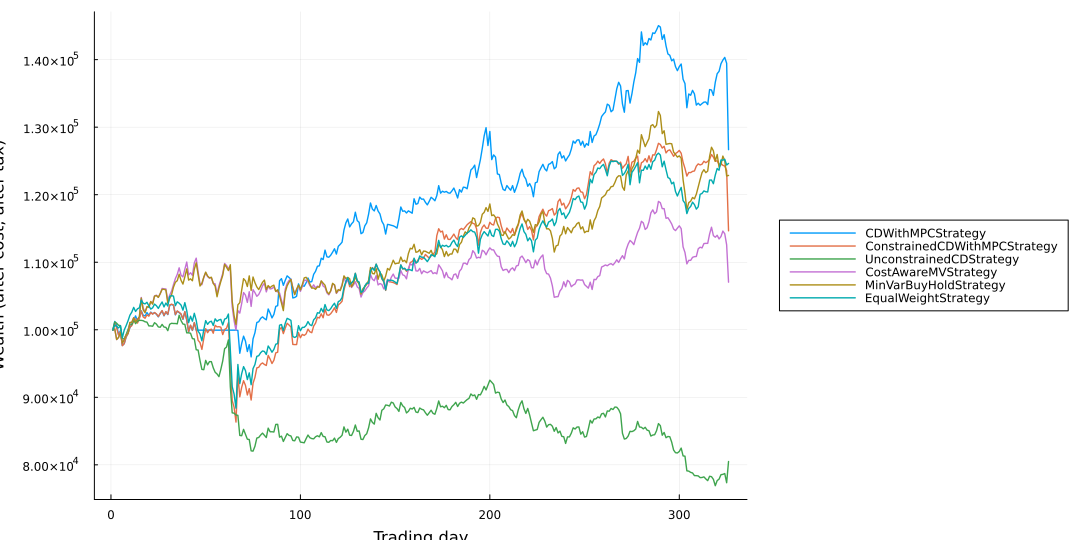

In [5]:
p = let
    plt = plot(legend = :outerright, size = (1080, 540),
               xlabel = "Trading day", ylabel = "Wealth (after-cost, after-tax)")
    for (name, r) in canonical
        plot!(plt, r.wealth_after_cost_aftertax; label = name, lw = 1.4)
    end
    plt
end


### MPC Trigger Reasons

Only the two MPC strategies (CDWithMPC, ConstrainedCDWithMPC) maintain a trigger log. Each fire is tagged with the condition that tripped it (out-of-band, $T$-day refresh, or the drawdown circuit-breaker), so we can see whether re-allocations are driven by realized drift or by the calendar. Counts shown are for the canonical reporting seed.


In [6]:
let
    for (name, r) in canonical
        if !isempty(r.trigger_log)
            reasons = [t.reason for t in r.trigger_log if t.fired]
            if !isempty(reasons)
                counts = Dict(rs => count(==(rs), reasons) for rs in unique(reasons))
                println(rpad(name, 35), "  ", counts)
            end
        end
    end
end;


CDWithMPCStrategy                    Dict(:drawdown => 4, :horizon_elapsed => 13, :band_exit => 3)
ConstrainedCDWithMPCStrategy         Dict(:drawdown => 11, :horizon_elapsed => 12, :band_exit => 2)


### Multi-Seed Backtest Distribution

The two MPC strategies depend on `BACKTEST_RNG_SEED` through their `forward_project` Monte Carlo paths. To honestly report performance we run each strategy across 20 seeds (`2001:2020`) and report the distribution of outcomes. The four non-MPC strategies (EW, MinVar, UnconstrainedCD, CostAwareMV) are deterministic given prices and collapse to a single value; they are included in the table to keep the row set uniform.


In [7]:
let
    rows = NamedTuple[]
    for (name, agg) in bt_mc["summary"]
        sh = agg["sharpe_mc"]
        dd = agg["max_dd_mc"]
        wt = agg["W_T_over_W0_mc"]
        push!(rows, (Strategy = name,
            Sharpe_min    = round(minimum(sh); digits = 3),
            Sharpe_med    = round(median(sh);  digits = 3),
            Sharpe_max    = round(maximum(sh); digits = 3),
            MaxDD_med_pct = round(median(dd) * 100; digits = 1),
            WT_W0_med     = round(median(wt); digits = 3),
            nTrig_med     = round(Int, median(agg["n_mpc_triggers_mc"]))))
    end
    sort!(rows; by = r -> -r.Sharpe_med)
    pretty_table(DataFrame(rows); backend = :text)
end;


┌──────────────────────────────┬────────────┬────────────┬────────────┬─────────
│                     Strategy │ Sharpe_min │ Sharpe_med │ Sharpe_max │ MaxDD_ ⋯
│                       String │    Float64 │    Float64 │    Float64 │        ⋯
├──────────────────────────────┼────────────┼────────────┼────────────┼─────────
│            CDWithMPCStrategy │      1.358 │      2.079 │      2.079 │        ⋯
│        MinVarBuyHoldStrategy │      1.199 │      1.199 │      1.199 │        ⋯
│          EqualWeightStrategy │       1.16 │       1.16 │       1.16 │        ⋯
│ ConstrainedCDWithMPCStrategy │      0.474 │      1.068 │      1.359 │        ⋯
│          CostAwareMVStrategy │      0.732 │      0.732 │      0.732 │        ⋯
│      UnconstrainedCDStrategy │     -1.263 │     -1.263 │     -1.263 │        ⋯
└──────────────────────────────┴────────────┴────────────┴────────────┴─────────
                                                               3 columns omitted


#### Sharpe distribution histogram for ConstrainedCDWithMPCStrategy

Hold-out Sharpe distribution for the constrained-CD + MPC design across the 20 backtest seeds. The four deterministic strategies (EW, MinVar, UnconstrainedCD, CostAwareMV) collapse to a single point; they do not vary with the RNG.


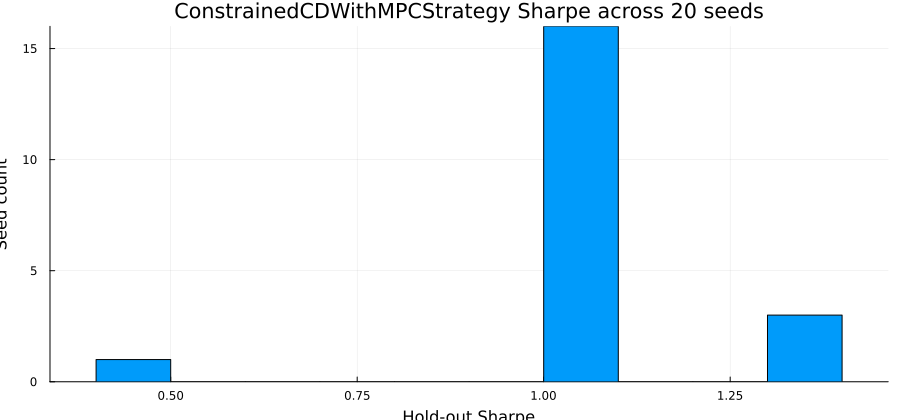

In [8]:
let
    sh = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]
    histogram(sh; bins = 10, xlabel = "Hold-out Sharpe", ylabel = "Seed count",
        title = "ConstrainedCDWithMPCStrategy Sharpe across $n_seeds seeds",
        legend = false, size = (900, 420))
end


___
## Summary

The MPC trigger discipline alone is the dominant fix. On the 2025-2026 hold-out, after costs and lot-by-lot FIFO taxes, **CDWithMPCStrategy** (unconstrained Cobb-Douglas allocation fired only on MPC trigger) delivers a hold-out Sharpe of **2.079** and max-drawdown of **8.4%**, the top strategy in the bake-off. The same unconstrained allocator at *daily cadence* (the live engine's allocator) collapses to Sharpe **-1.263** and max-drawdown **24.7%**, with annualized turnover of about 241× the portfolio (the flat-with-bleed live failure mode reproduced in backtest). The MPC trigger alone takes the strategy from disaster to top performer; adding the covariance, turnover, and concentration constraints (ConstrainedCDWithMPCStrategy) moves Sharpe back to **1.068** and raises max-drawdown to **16.8%**. In this regime the constraint layer is net-negative.

> **Key Takeaways:**
>
> * **Cadence is the load-bearing fix:** The trigger-only step from daily rebalance to MPC trigger moves the unconstrained Cobb-Douglas strategy from worst to best in the bake-off, while adding the covariance and turnover constraints on top reverses much of that gain. The constraint layer is net-negative in this trend regime because the tight covariance budget suppresses the high-conviction allocations the hold-out window rewarded.
> * **The dominant trigger reason is the calendar refresh, not the band exit:** The realized portfolio path rarely leaves the 95% forward-projection band on its own, so most re-allocations are driven by the periodic horizon timer or the drawdown circuit-breaker. The constrained variant fires the drawdown circuit-breaker far more often than the unconstrained-MPC variant, which signals the circuit-breaker is doing the protective work the per-decision constraints fail to do.
> * **Read distributions, not single trials:** The two MPC strategies are stochastic in their forward-projection Monte Carlo paths, so the 20-seed median is the honest summary statistic and any single seed misrepresents the strategy. The four deterministic baselines collapse to a single point per metric, which is directly comparable to the MC median rather than to any individual seed.

This closes the loop opened by the live-engine post-mortem in `constrained_cobb_douglas.md`. The original engine had no notion of cost, no notion of risk, no notion of holding, and fired on a clock with no information content. **The MPC discipline (T-day refresh plus drawdown circuit-breaker) fixes the cadence problem on its own.** The data argues the constraint layer, as currently calibrated, needs hyperparameter tuning before it can add value here; a sensitivity sweep over $\sigma_{\max}$ and $K_{\text{turnover}}$ would be the natural next experiment.

### Disclaimer

This content is for educational purposes only and does not constitute investment advice. The examples use real historical data, a frozen SIM calibration on 2014-2024, and a single 2025-2026 forward window; conclusions about cost-aware constrained allocation and MPC trigger discipline do not generalize to other markets, time periods, or client risk profiles without re-calibration.

___
